In [1]:
from evoscape.jax.flax_models.landscape_flax import LandscapeFlax
from evoscape.jax.flax_models.autoencoder_flax import AutoEncoder

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax import nnx

from evoscape.landscapes import Landscape
from evoscape.modules import Node
from evoscape.morphogen_regimes import mr_const, mr_sigmoid
from evoscape.landscape_visuals import plot_traj, visualize_landscape, visualize_landscape_t
from evoscape.jax.dynamics import state_probs
from evoscape.jax.utils import get_drosophile_data, get_facs_data
from evoscape.jax.config import DATA_DIR
from evoscape.jax.losses import mmd_traj, sinkhorn_traj

plt.style.use("default")

## Creating the landscape and the autoencoder

Landscape with modules:
Node: x=-2.0; y=-1.5; a=[1.,1.]; s=[1.,1.]; tau=1.0,
Node: x=0.0; y=-1.5; a=[1.,1.]; s=[1.,1.]; tau=1.0,
Node: x=2.0; y=-1.5; a=[1.,1.]; s=[1.,1.]; tau=1.0,
Node: x=-2.0; y=1.5; a=[1.,1.]; s=[1.,1.]; tau=1.0,
Node: x=0.0; y=1.5; a=[1.,1.]; s=[1.,1.]; tau=1.0,
Node: x=2.0; y=1.5; a=[1.,1.]; s=[1.,1.]; tau=1.0


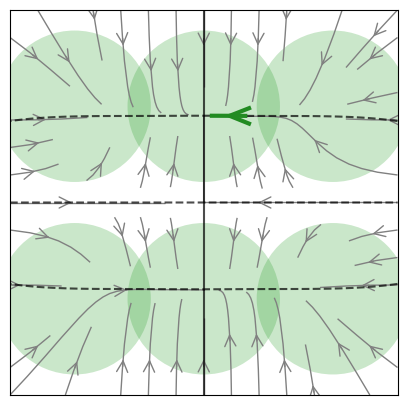

In [2]:
# modules = (
#     Node(x=1.5, y=0.0, a=np.array(1.5), s=np.array(1.0)),
#     Node(x=-2.5, y=0.0, a=np.array(1.5), s=np.array(1.0)),
# )

def create_module_grid(x, y):
    xx, yy = np.meshgrid(x,y)
    modules = [Node(x=x, y=y, a=np.array([1.0, 1.0]), s=np.array([1.0, 1.0]), tau=1.) for x,y in zip(xx.flatten(), yy.flatten())]
    return modules

x = [-2., 0., 2.]
y = [-1.5, 1.5]
modules = create_module_grid(x, y)

landscape = Landscape(
    module_list=modules,
    A0=0.05,
    init_cond=(0.0, 0.0),
    regime=mr_sigmoid,
    n_regimes=2,
    morphogen_times=(50.,),
)

print(landscape)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape_t(landscape, xx, yy, 2., color_scheme='fp_types', traj_times=(0., 20., 201), traj_init_cond=(2.,2.), traj_start=100)


In [3]:

# Initializing the landscape 
rngs = nnx.Rngs(0)
landscape_flax = LandscapeFlax(landscape, rngs)

landscape_flax.set_simulation(init_noise=0.2, t0=20.0, tf=200.0, nt=7, ndt=100, noise=0.2)
landscape_flax.set_regime_params(signal_param=None)
landscape_flax.set_state_probs(state_probs)

# Initialiazing the decoder
dims_encoder = [5,2]
dims_decoder = [2,4,5]

autoencoder = AutoEncoder(landscape_flax, dims_decoder=dims_decoder, dims_encoder=dims_encoder, rngs=rngs)

## Loading the data

In [4]:
filepath = DATA_DIR / "df_CHIR 2-3_clean.csv"

target_traj, timepoints = get_facs_data(filepath)

# there are too many cells, I only choose 200 of them randomly
indices = np.random.choice(target_traj.shape[1], size=200, replace=False)
target_traj = target_traj[:, indices, :]

print(target_traj.shape)
print(timepoints)


(5, 200, 7)
[2.  2.5 3.  3.5 4.  4.5 5. ]


In [5]:
q_init = target_traj[:, :, 0]
print(q_init.shape)

simulated_traj = autoencoder(q_init)
print(simulated_traj.shape)

loss = mmd_traj(simulated_traj, target_traj)
print(loss)

(5, 200)
(5, 200, 7)
5.395513


(5, 200)
(2, 200)


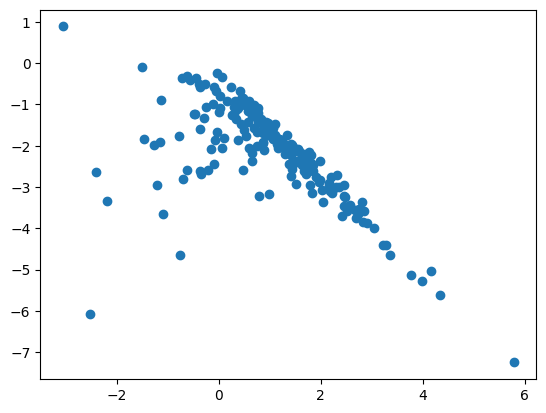

In [6]:
print(q_init.shape)
q_init_latent = nnx.vmap(lambda x : autoencoder.encoder(x), in_axes=1, out_axes=1)(q_init) # (2, n)

print(q_init_latent.shape)
plt.scatter(q_init_latent[0,:], q_init_latent[1,:])

## Training the model

Époque 0 | Loss: 106.7535
Époque 50 | Loss: 69.7926
Époque 100 | Loss: 47.4302
Époque 150 | Loss: 44.4131
Époque 200 | Loss: 38.4070
Époque 250 | Loss: 35.5098
Époque 300 | Loss: 31.5202
Époque 350 | Loss: 26.2329
Époque 400 | Loss: 23.3396
Époque 450 | Loss: 22.7405
Époque 500 | Loss: 22.0904
Époque 550 | Loss: 22.4382
Époque 600 | Loss: 23.2479
Époque 650 | Loss: 21.1545
Époque 700 | Loss: 20.3273
Époque 750 | Loss: 19.6162


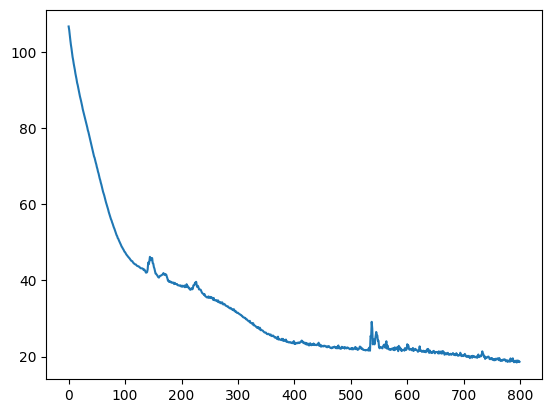

In [ ]:
# Defining the optimizer 

optimizer = nnx.Optimizer(autoencoder, optax.adam(2e-3), wrt=nnx.Param)

# Defining the loss function, and the train_step 

def loss_fn(autoencoder, target_traj):
    # Forward pass
    q_init = target_traj[:,:,0]
    simulated_traj = autoencoder(q_init)

    # Loss on cloud points
    loss_dynamics = mmd_traj(simulated_traj, target_traj)

    # Loss on encoding the trajectory
    encoded_decoded_traj = autoencoder.forward_no_dynamics(target_traj)

    loss_encoding = jnp.sum((encoded_decoded_traj - target_traj)**2)
    
    return loss_dynamics + 1e-3*loss_encoding


@nnx.jit
def train_step(autoencoder, optimizer: nnx.Optimizer, target_traj):
    # nnx.value_and_grad computes the gradient with respect to the nnx.Params
    loss, grads = nnx.value_and_grad(loss_fn)(autoencoder, target_traj)
    
    optimizer.update(autoencoder, grads)
    
    return loss

# Training loop 
n_epochs = 800
loss_vals = []

for epoch in range(n_epochs):
    loss_val = train_step(autoencoder, optimizer, target_traj)
    
    if epoch%50 == 0:
        print(f"Époque {epoch} | Loss: {loss_val:.4f}")

    loss_vals.append(loss_val)

plt.plot(loss_vals)

Landscape with modules:
Node: x=-2.227263927459717; y=-1.8331141471862793; a=[1.1211597,1.0418686]; s=[1.054385,1.042567]; tau=1.0,
Node: x=0.11279162764549255; y=-1.615036129951477; a=[0.99802214,0.89147621]; s=[0.9494392,0.9117407]; tau=1.0,
Node: x=2.0171313285827637; y=-1.6533225774765015; a=[0.9567734,1.0602415]; s=[0.9618133,0.9092081]; tau=1.0,
Node: x=-2.273843288421631; y=1.505789875984192; a=[0.9308445,0.9462075]; s=[0.9778718,0.9178866]; tau=1.0,
Node: x=-0.04630649462342262; y=1.351415753364563; a=[1.0048326,1.0125115]; s=[0.92155516,1.03213096]; tau=1.0,
Node: x=2.1248350143432617; y=1.59244966506958; a=[0.8772273,0.8100887]; s=[0.92052674,0.84725356]; tau=1.0


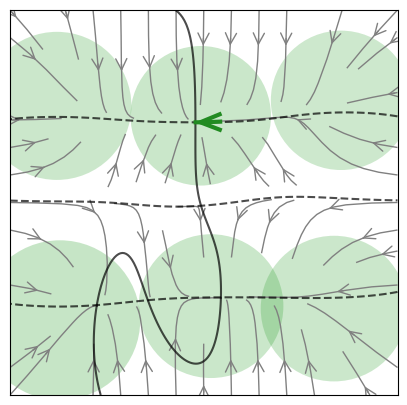

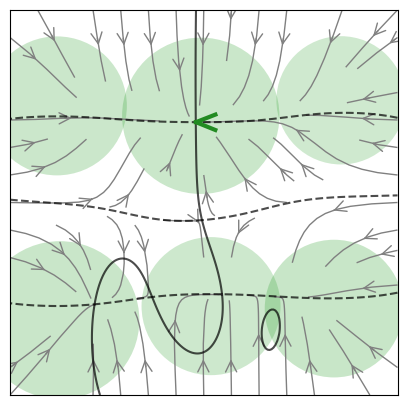

In [8]:
landscape = autoencoder.landscape_flax.get_landscape()

print(landscape)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape_t(landscape, xx, yy, 20., color_scheme='fp_types', traj_times=(0., 20., 201), traj_init_cond=(2.,2.), traj_start=100)
fig = visualize_landscape_t(landscape, xx, yy, 200., color_scheme='fp_types', traj_times=(0., 20., 201), traj_init_cond=(2.,2.), traj_start=100)

## Analyzing the model

(5, 200)
(2, 200)


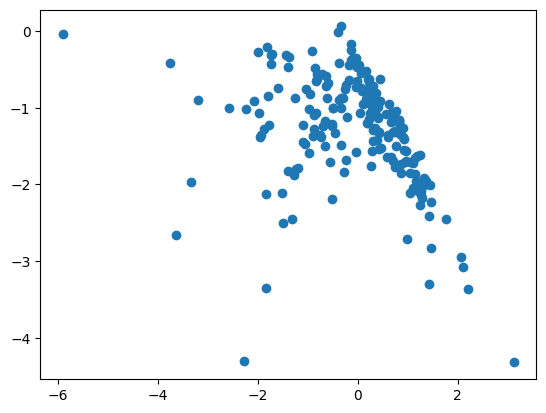

In [9]:
print(q_init.shape)
q_init_latent = nnx.vmap(lambda x : autoencoder.encoder(x), in_axes=1, out_axes=1)(q_init) # (2, n)

print(q_init_latent.shape)
plt.scatter(q_init_latent[0,:], q_init_latent[1,:])

(2, 200, 7)


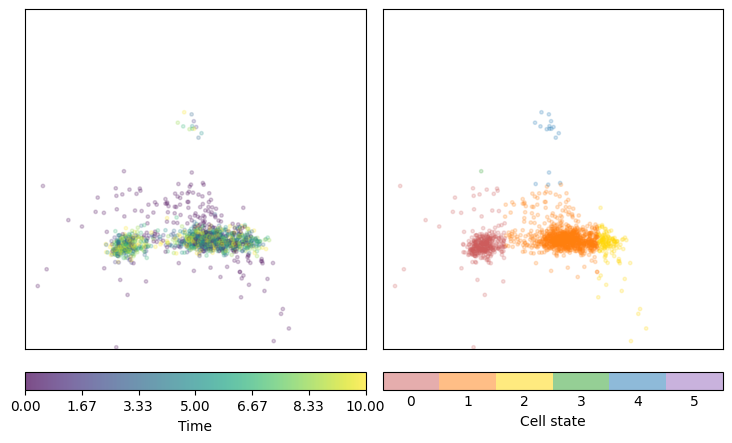

In [10]:
t0=0.0
tf=10.0
nt=7
traj, states = autoencoder.landscape_flax(q_init_latent)

print(traj.shape)

fig = plot_traj(traj, states, t0, tf, nt, L=4)